<a href="https://colab.research.google.com/github/Not-kh-lily-23/EcoSpike-Audio/blob/main/baseline_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
from google.colab import drive
import os
import urllib.request
import zipfile
import pandas as pd
drive.mount('/content/drive')
project='/content/drive/MyDrive/EcoSpike'
os.makedirs(project,exist_ok=True)
os.chdir(project)
if not os.path.exists('ESC-50-master'):
    urllib.request.urlretrieve('https://github.com/karolpiczak/ESC-50/archive/master.zip','esc50.zip')
    with zipfile.ZipFile('esc50.zip','r') as zip_ref:
        zip_ref.extractall('.')
    os.remove('esc50.zip')
    print("dataset in drive")
else:
    print("dataset already in Drive.")
df=pd.read_csv('ESC-50-master/meta/esc50.csv')
t_classes={
    41:'chainsaw',
    40:'helicopter',
    44:'engine',
    14:'chirping_birds',
    7:'insects',
    10:'rain',
    16:'wind'
}
df_filt=df[df['target'].isin(t_classes.keys())].copy()
df_trn=df_filt[df_filt['fold']<5]
df_tst=df_filt[df_filt['fold']==5]
print(f"total training clips (folds 1-4): {len(df_trn)}")
print(f"total test clips (fold 5): {len(df_tst)}")
print("target class breakdown:")
print(df_filt['category'].value_counts())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
dataset already in Drive.
total training clips (folds 1-4): 224
total test clips (fold 5): 56
target class breakdown:
category
chirping_birds    40
chainsaw          40
wind              40
helicopter        40
rain              40
insects           40
engine            40
Name: count, dtype: int64


spectrogram tensor shape: torch.Size([1, 64, 501])
mapped label id: 3 (original esc-50 id: 14)


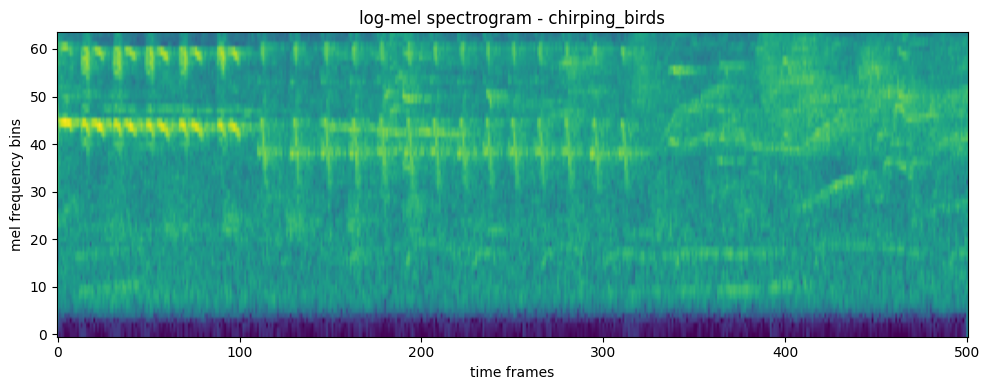

In [7]:
import torch
import torchaudio
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
lbl_map={original: new for new,original in enumerate(t_classes.keys())}
reverse_lbl_map={new: original for new,original in enumerate(t_classes.keys())}
class eco_spike_dset(Dataset):
    def __init__(self,df,audio_dir,transform=None):
        self.df=df.reset_index(drop=True)
        self.audio_dir=audio_dir
        self.transform=transform
    def __len__(self):
        return len(self.df)
    def __getitem__(self,idx):
        f_name=self.df.loc[idx,'filename']
        f_path=os.path.join(self.audio_dir,f_name)
        waveform,sr=torchaudio.load(f_path)
        if sr!=16000:
            resmpl=torchaudio.transforms.Resample(orig_freq=sr,new_freq=16000)
            waveform=resmpl(waveform)
        if self.transform:
            spectro=self.transform(waveform)
        og_lbl=self.df.loc[idx,'target']
        mapped_lbl=lbl_map[og_lbl]
        return spectro,mapped_lbl
mel_transform=torchaudio.transforms.MelSpectrogram(sample_rate=16000,n_mels=64,n_fft=400,hop_length=160)
trn_dset=eco_spike_dset(df=df_trn,audio_dir='ESC-50-master/audio',transform=mel_transform)
spec,label=trn_dset[0]
print(f"spectrogram tensor shape: {spec.shape}")
print(f"mapped label id: {label} (original esc-50 id: {reverse_lbl_map[label]})")
plt.figure(figsize=(10,4))
plt.imshow(torch.log(spec[0]+1e-6).numpy(),cmap='viridis',origin='lower',aspect='auto')
plt.title(f'log-mel spectrogram - {t_classes[reverse_lbl_map[label]]}')
plt.ylabel('mel frequency bins')
plt.xlabel('time frames')
plt.tight_layout()
plt.show()

In [8]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
class audiocnn(nn.Module):
    def __init__(self, num_classes=7):
        super().__init__()
        self.features=nn.Sequential(
            nn.Conv2d(1,16,kernel_size=3,padding=1),nn.ReLU(),nn.MaxPool2d(kernel_size=2,stride=2),
            nn.Conv2d(16,32,kernel_size=3,padding=1),nn.ReLU(),nn.MaxPool2d(kernel_size=2,stride=2),
            nn.Conv2d(32,64,kernel_size=3,padding=1),nn.ReLU(),nn.MaxPool2d(kernel_size=2,stride=2),
            nn.Conv2d(64,128,kernel_size=3,padding=1),nn.ReLU(),nn.MaxPool2d(kernel_size=2,stride=2)
        )
        self.global_pool=nn.AdaptiveAvgPool2d((1,1))
        self.flatten=nn.Flatten()
        self.fc=nn.Linear(128,num_classes)
    def forward(self,x):
        x=self.features(x)
        x=self.global_pool(x)
        x=self.flatten(x)
        x=self.fc(x)
        return x
bline_mdl=audiocnn(num_classes=7)
total_prm=sum(p.numel() for p in bline_mdl.parameters() if p.requires_grad)
print(f"the total number of trainable parameters are {total_prm:,}")
dummy_input=torch.randn(1,1,64,501)
print(f"tensor shape: {bline_mdl(dummy_input).shape}")
trn_loader=DataLoader(trn_dset,batch_size=16,shuffle=True)
tst_dataset=eco_spike_dset(df=df_tst,audio_dir='ESC-50-master/audio',transform=mel_transform)
tst_loader=DataLoader(tst_dataset,batch_size=16,shuffle=False)
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
mdl=bline_mdl.to(device)
crt=nn.CrossEntropyLoss()
opt=optim.Adam(mdl.parameters(), lr=0.001)
epochs=15
best_acc=0.0
for epoch in range(epochs):
    mdl.train()
    r_loss=0.0
    for inputs,lbl in trn_loader:
        inputs,lbl=inputs.to(device),lbl.to(device)
        opt.zero_grad()
        outputs=mdl(inputs)
        loss=crt(outputs,lbl)
        loss.backward()
        opt.step()
        r_loss+=loss.item()
    mdl.eval()
    correct=0
    total=0
    with torch.no_grad():
        for inputs,lbl in tst_loader:
            inputs,lbl=inputs.to(device),lbl.to(device)
            outputs=mdl(inputs)
            predicted=outputs.argmax(dim=1)
            total+=lbl.size(0)
            correct+=(predicted==lbl).sum().item()
    val_acc=(correct/total)*100
    print(f"epoch {epoch+1:02d}/{epochs} - loss: {r_loss/len(trn_loader):.4f} - validation aCcuracy: {val_acc:.2f}%")
    if val_acc>best_acc:
        best_acc=val_acc
        torch.save(mdl.state_dict(),'/content/drive/MyDrive/EcoSpike/best_cnn_baseline.pth')
print(f"best validation accuracy is {best_acc:.2f}%")

the total number of trainable parameters are 98,055
tensor shape: torch.Size([1, 7])
epoch 01/15 - loss: 2.3131 - validation aCcuracy: 32.14%
epoch 02/15 - loss: 1.7472 - validation aCcuracy: 39.29%
epoch 03/15 - loss: 1.6687 - validation aCcuracy: 41.07%
epoch 04/15 - loss: 1.5785 - validation aCcuracy: 37.50%
epoch 05/15 - loss: 1.4018 - validation aCcuracy: 44.64%
epoch 06/15 - loss: 1.3252 - validation aCcuracy: 46.43%
epoch 07/15 - loss: 1.1745 - validation aCcuracy: 48.21%
epoch 08/15 - loss: 1.0975 - validation aCcuracy: 57.14%
epoch 09/15 - loss: 1.1028 - validation aCcuracy: 51.79%
epoch 10/15 - loss: 1.0070 - validation aCcuracy: 48.21%
epoch 11/15 - loss: 0.9178 - validation aCcuracy: 57.14%
epoch 12/15 - loss: 0.8827 - validation aCcuracy: 57.14%
epoch 13/15 - loss: 0.8938 - validation aCcuracy: 62.50%
epoch 14/15 - loss: 0.7989 - validation aCcuracy: 60.71%
epoch 15/15 - loss: 0.9117 - validation aCcuracy: 53.57%
best validation accuracy is 62.50%


In [9]:
!pip install snntorch
import snntorch as snn
from snntorch import surrogate
import snntorch.utils
import torch.optim as optim
class AudioSNN(nn.Module):
    def __init__(self,num_classes=7):
        super().__init__()
        spike_grad=surrogate.fast_sigmoid(slope=25)
        beta=0.9
        self.features=nn.Sequential(
            nn.Conv2d(1,16,kernel_size=3,padding=1),
            nn.MaxPool2d(kernel_size=2,stride=2),
            snn.Leaky(beta=beta,spike_grad=spike_grad,init_hidden=True),
            nn.Conv2d(16,32,kernel_size=3,padding=1),
            nn.MaxPool2d(kernel_size=2,stride=2),
            snn.Leaky(beta=beta,spike_grad=spike_grad,init_hidden=True),
            nn.Conv2d(32,64,kernel_size=3,padding=1),
            nn.MaxPool2d(kernel_size=2,stride=2),
            snn.Leaky(beta=beta,spike_grad=spike_grad,init_hidden=True),
            nn.Conv2d(64,128,kernel_size=3,padding=1),
            nn.MaxPool2d(kernel_size=2,stride=2),
            snn.Leaky(beta=beta,spike_grad=spike_grad,init_hidden=True)
        )
        self.global_pool=nn.AdaptiveAvgPool2d((1,1))
        self.flatten=nn.Flatten()
        self.fc=nn.Linear(128,num_classes)
        self.lif_fc=snn.Leaky(beta=beta,spike_grad=spike_grad,init_hidden=True,output=True)
    def forward(self,x):
        snn.utils.reset(self)
        num_steps=25
        spk_rec=[]
        mem_rec=[]
        for step in range(num_steps):
            cur=self.features(x)
            cur=self.global_pool(cur)
            cur=self.flatten(cur)
            cur=self.fc(cur)
            spk,mem=self.lif_fc(cur)
            spk_rec.append(spk)
            mem_rec.append(mem)
        return torch.stack(spk_rec,dim=0),torch.stack(mem_rec,dim=0)
snn_mdl=AudioSNN(num_classes=7)
total_snn_params=sum(p.numel() for p in snn_mdl.parameters() if p.requires_grad)
print(f"SNN trainable parameters: {total_snn_params:,}")
dummy_input=torch.randn(1,1,64,501)
spk_out,mem_out=snn_mdl(dummy_input)
print(f"output spike tensor shape: {spk_out.shape} (expected: [25, 1, 7])")
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
snn_mdl=snn_mdl.to(device)
crtr=nn.CrossEntropyLoss()
opt=optim.Adam(snn_mdl.parameters(),lr=0.001)
epochs=25
best_snn_acc=0.0
for epoch in range(epochs):
    snn_mdl.train()
    r_loss=0.0
    for inputs,lbl in trn_loader:
        inputs,lbl=inputs.to(device),lbl.to(device)
        opt.zero_grad()
        spk_out,mem_out=snn_mdl(inputs)
        sum_spk_out=spk_out.sum(dim=0)
        loss=crtr(sum_spk_out,lbl)
        loss.backward()
        opt.step()
        r_loss+=loss.item()
    snn_mdl.eval()
    correct=0
    total=0
    with torch.no_grad():
        for inputs,lbl in tst_loader:
            inputs,lbl=inputs.to(device),lbl.to(device)
            spk_out,mem_out=snn_mdl(inputs)
            sum_spk_out=spk_out.sum(dim=0)
            predicted=sum_spk_out.argmax(dim=1)
            total+=lbl.size(0)
            correct+=(predicted==lbl).sum().item()
    val_acc=(correct/total)*100
    print(f"epoch {epoch+1:02d}/{epochs} - SNN loss: {r_loss/len(trn_loader):.4f} - SNN val accuracy: {val_acc:.2f}%")
    if val_acc>best_snn_acc:
        best_snn_acc=val_acc
        torch.save(snn_mdl.state_dict(),'/content/drive/MyDrive/EcoSpike/best_snn_model.pth')
print(f"best SNN val accuracy: {best_snn_acc:.2f}%")

SNN trainable parameters: 98,055
output spike tensor shape: torch.Size([25, 1, 7]) (expected: [25, 1, 7])
epoch 01/25 - SNN loss: 1.9489 - SNN val accuracy: 14.29%
epoch 02/25 - SNN loss: 2.0174 - SNN val accuracy: 14.29%
epoch 03/25 - SNN loss: 1.9594 - SNN val accuracy: 14.29%
epoch 04/25 - SNN loss: 1.9165 - SNN val accuracy: 23.21%
epoch 05/25 - SNN loss: 1.8938 - SNN val accuracy: 28.57%
epoch 06/25 - SNN loss: 1.8782 - SNN val accuracy: 28.57%
epoch 07/25 - SNN loss: 1.8431 - SNN val accuracy: 28.57%
epoch 08/25 - SNN loss: 1.7919 - SNN val accuracy: 26.79%
epoch 09/25 - SNN loss: 1.7701 - SNN val accuracy: 35.71%
epoch 10/25 - SNN loss: 1.7015 - SNN val accuracy: 33.93%
epoch 11/25 - SNN loss: 1.6654 - SNN val accuracy: 39.29%
epoch 12/25 - SNN loss: 1.6565 - SNN val accuracy: 28.57%
epoch 13/25 - SNN loss: 1.7669 - SNN val accuracy: 32.14%
epoch 14/25 - SNN loss: 1.6924 - SNN val accuracy: 42.86%
epoch 15/25 - SNN loss: 1.6398 - SNN val accuracy: 33.93%
epoch 16/25 - SNN loss: 